## Logistic Regression Example: Predicting Touchdown Probability ##

On any given offensive play in football, there is a probability that one of the teams scores a touchdown (TD). This example seeks to use our logistic regression class to estimate that probability. 

In [1]:
import numpy as np
import rice_ml
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

First, we load in our data, which contains play-by-play data from the 2025-2026 season on down, distance, and the yards to the goaline from the offense's perspective. The data also contains a binary variable indicating if a TD occured on that play.  

In [22]:
# Load in NFL receiving stats dataset
csv_path = Path("..") / "data" / "NFL_pbp.csv"
data = pd.read_csv(csv_path)
# Display the first 5 rows of the dataset
data.head(5)

,Unnamed: 0,down,ydstogo,yardline_100,touchdown
0,1,NaN,0,NaN,NaN
1,2,NaN,0,35.0,0.0
2,3,1.0,10,78.0,0.0
3,4,2.0,7,75.0,0.0
4,5,1.0,10,64.0,0.0


To ensure that we only have offensive snaps, we will remove all plays where down is NULL. These plays are all special teams plays such as kickoffs, punts, or extra points. For ease of computation when training the model, we will standardize the ydstogo and yardline_100 feature vectors to reduce the magnitude.  

In [23]:
# Filter out rows with missing values
data = data.dropna()

# standardize ydstogo and yardline_100 features
ydstogo_std = rice_ml.StandardScaler()
yardline_100_std = rice_ml.StandardScaler()
data["ydstogo"] = ydstogo_std.fit_transform(data[["ydstogo"]])
data["yardline_100"] = yardline_100_std.fit_transform(data[["yardline_100"]])

# One-hot encode the down feature
down_ohe = rice_ml.OneHotEncoder()
down_encoded = down_ohe.fit_transform(data["down"].values)

# Combine standardized, one hot encoded features, and touchdown variable into a single dataset
X = np.hstack((data[["ydstogo", "yardline_100"]].values, down_encoded))
y = data["touchdown"].values


Now that our data is clean, we need to split it into training and testing data. We decided to use 80% of the data to train the model and 20% to test it. 

In [24]:
np.random.seed(42)

# Generate a shuffled array of indices based on the length of our dataset
shuffled_indices = np.random.permutation(len(X))

# Calculate the index at which to split (80% train, 20% test)
split_idx = int(0.8 * len(X))

# Separate the indices into train and test groups
train_indices = shuffled_indices[:split_idx]
test_indices = shuffled_indices[split_idx:]

# 6. Apply the indices to create the final Train and Test sets
X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

#inspect training data
print("Training Data:")
print(X_train[:5])
print(y_train[:5])

Training Data:
[[ 0.38497304  0.24184743  1.          0.          0.          0.        ]
 [ 0.38497304  0.24184743  1.          0.          0.          0.        ]
 [ 0.38497304 -0.26064641  0.          0.          1.          0.        ]
 [ 0.38497304  0.19997294  1.          0.          0.          0.        ]
 [ 0.38497304 -0.55376782  0.          1.          0.          0.        ]]
[0. 0. 0. 0. 0.]


For our model, we will use the Logistic Regression class from the rice_ml package. When initializing, we provide the eta (learning rate) and epochs (runs through training set). To train, we will use the train method, which takes the feature vector array and target vector array as arguements.  

Model Bias: -2.0838
------------------------------
Model Weights:
       distance: -0.1215
 yds to goaline: -0.4198
         down_1: -0.7355
         down_2: -0.6161
         down_3: -0.4431
         down_4: -0.2890


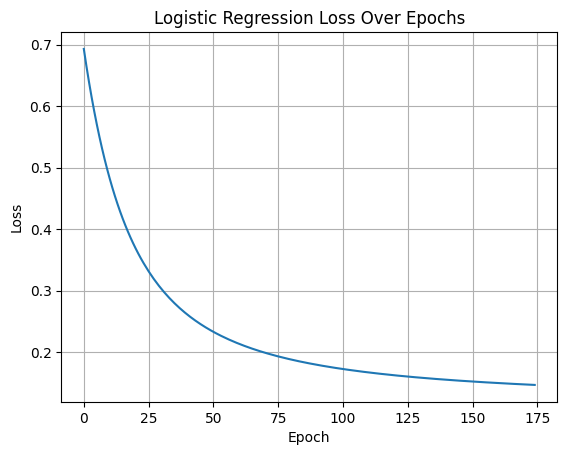

In [42]:
# Train logistic regression model on training data
model = rice_ml.LogisticRegression(eta = 0.1, epochs = 175)
model.train(X, y)

#One hot features
down_features = [f"down_{int(cat)}" for cat in down_ohe.categories_]

#feature names
feature_names = ["distance", "yds to goaline"] + down_features

# Show model bias and weights
print(f"Model Bias: {model.bias:.4f}")
print("-" * 30)
print("Model Weights:")

# Use zip() to pair each name with its corresponding weight
for name, weight in zip(feature_names, model.weights):
    print(f"{name:>15}: {weight:.4f}")

# Plot model losses over epochs
plt.plot(model.losses)
plt.title("Logistic Regression Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

Looking at our model summary, we see that the distance to a first down does not play a large role in TD probability. As the offesne gets farther away from the goaline, the TD probability decreases, which makes sense intuitively. Interestingly, as the down increases, TD probability also increases. This is likely a sample size issue: since there are more first downs than any other down, and more of those downs are further away from the goaline than other downs. Thus, there is a higher proportion of first downs that do not result in a TD. While this is mathematically correct, we can say that down is likely not a good predictor of touchdowns independent of field position. 

Additionally, we can see from the plot that our loss decreases as the epochs progress, and does not stagnate within our choses epoch range. This indicates that we have chosen an appropriate training time and are not overfitting the data.  

To test our model, we have two options. The predict method will predict a binary outcome (touchdown or no touchdown). The predict_proba method will predict the probability of a touchdown. Since we are trying to predict the probability of a given play ending in a touchdown, we will use predict_proba. For both of these methods, we only need to provide the feature vector array. They return the predicted probabilities as an array. 

Brier Score: 0.0373


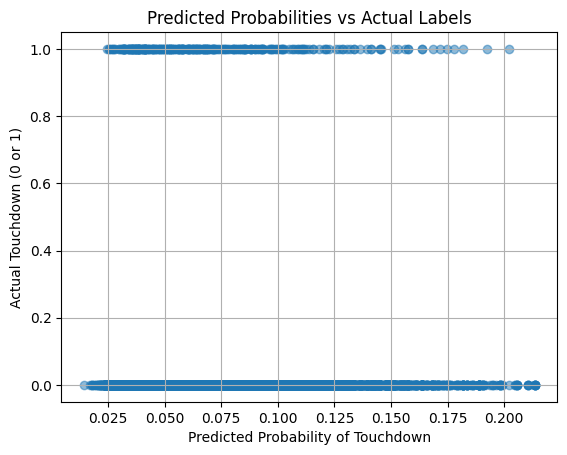

In [49]:
# Test the model on the testing data
predictions = model.predict_proba(X_test)

# calculate brier score
brier_score = rice_ml.mean_squared_error(y_test, predictions)
print(f"Brier Score: {brier_score:.4f}")

# Plot predicted probabilities vs actual labels with logistic line
log_odds = np.dot(X_test, model.weights) + model.bias
sorted_indices = np.argsort(log_odds)
log_odds_sorted = log_odds[sorted_indices]
predictions_sorted = predictions[sorted_indices]


plt.scatter(predictions, y_test, alpha=0.5)
plt.title("Predicted Probabilities vs Actual Labels")
plt.xlabel("Predicted Probability of Touchdown")
plt.ylabel("Actual Touchdown (0 or 1)")
plt.grid()
plt.show()

To evaluate our model, we use a Brier Score and plot our predicted probabilities against the actual outcomes in the test set. The Brier Score is at 0.0373, indicating that on average, the predicted probability devaites by 3.73 percentage points from the true TD percentage. Since the probabilities only range from about 0-0.2, this deviance is quite high. Furthermore, we can see from the plot that the actual touchdowns do not seem to increase or decrease as the probability increases. Due to the large number of points, it is hard to draw a conclusive trend. We can use a calibration plot to see if the probabilities are accurate. 

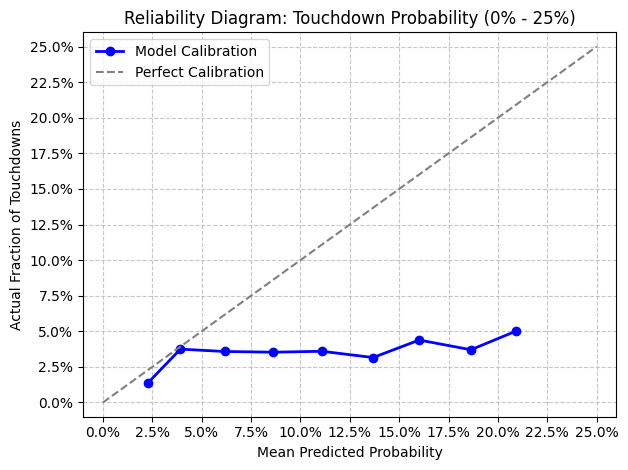

In [ ]:
# Calibration plot with bins every 2.5% predicted probability
bins = np.arange(0.0, 0.275, 0.025)
mean_predicted_probs = []
actual_touchdown_fractions = []

# Iterate through each bin to calculate the metrics
for i in range(len(bins) - 1):
    lower_bound = bins[i]
    upper_bound = bins[i+1]
    
    # Create a boolean mask to find which predictions fall into this specific bin
    in_bin_mask = (predictions >= lower_bound) & (predictions < upper_bound)
    
    # Only calculate if there is at least one prediction in this bin to avoid division by zero
    if np.any(in_bin_mask):
        # Calculate the mean predicted probability in this bin
        mean_pred = np.mean(predictions[in_bin_mask])
        
        # Calculate the actual fraction of touchdowns in this bin
        # Since y_test is 0 or 1, the mean perfectly equals the fraction of 1s
        true_fraction = np.mean(y_test[in_bin_mask])
        
        mean_predicted_probs.append(mean_pred)
        actual_touchdown_fractions.append(true_fraction)

# Plot the curve
plt.plot(mean_predicted_probs, actual_touchdown_fractions, marker='o', linestyle='-', 
         color='blue', linewidth=2, label='Model Calibration')

# Plot the perfectly calibrated reference line (y = x)
plt.plot([0, 0.25], [0, 0.25], linestyle='--', color='gray', label='Perfect Calibration')

# Format the plot strictly to the 0-25% range
plt.xlim([-0.01, 0.26]) 
plt.ylim([-0.01, 0.26])

# Set x-ticks exactly at your 2.5% bin edges for perfect readability
plt.xticks(bins, labels=[f"{b*100:.1f}%" for b in bins])
# Format y-ticks as percentages too
plt.yticks(bins, labels=[f"{b*100:.1f}%" for b in bins])
plt.title("Calibration Diagram: Touchdown Probability (0% - 25%)")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Fraction of Touchdowns")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

As we can see from the calibration plot, this model does not accurately predict touchdown probability. Overall, this is not a sound model and has no predictive power. This lack of power is likely due in part to the issues mentioned above with down sample sizes. Additionally, there is a lot of noise in football, and TDs are incredibly rare on a play-by-play basis, which makes them hard to predict. Overall, while the model is implemented and tested in a mathematically sound fashion, it does not have any predictive power.